In [26]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from scipy import stats

In [17]:
# Load the dataset
file_path = 'LengthOfStay (1).csv'  # Replace with your file path
df = pd.read_csv(file_path)


In [18]:
# Drop irrelevant columns
df_cleaned = df.drop(columns=['eid', 'vdate', 'facid', 'discharged'])

# Encode categorical variables: 'gender' and 'rcount'
df_cleaned['gender'] = df_cleaned['gender'].map({'M': 1, 'F': 0})
df_cleaned['rcount'] = df_cleaned['rcount'].replace({'5+': 5}).astype(int)


# Handle missing data (fill missing values with mean)
df_cleaned.fillna(df_cleaned.mean(), inplace=True)

# Convert the target column: lengthofstay >= 7 -> 1 (extended stay), otherwise 0
df_cleaned['extended_stay'] = (df_cleaned['lengthofstay'] >= 7).astype(int)

# Drop the original 'lengthofstay' column
df_cleaned = df_cleaned.drop(columns=['lengthofstay'])


# Data Exploration: Generate Table 1 (descriptive statistics)
print("Descriptive Statistics (Table 1):")
print(df_cleaned.describe())

Descriptive Statistics (Table 1):
              rcount         gender  dialysisrenalendstage         asthma  \
count  100000.000000  100000.000000          100000.000000  100000.000000   
mean        1.118210       0.423570               0.036420       0.035270   
std         1.542958       0.494126               0.187334       0.184462   
min         0.000000       0.000000               0.000000       0.000000   
25%         0.000000       0.000000               0.000000       0.000000   
50%         0.000000       0.000000               0.000000       0.000000   
75%         2.000000       1.000000               0.000000       0.000000   
max         5.000000       1.000000               1.000000       1.000000   

             irondef          pneum  substancedependence  \
count  100000.000000  100000.000000        100000.000000   
mean        0.094940       0.039450             0.063060   
std         0.293134       0.194664             0.243072   
min         0.000000       0.000

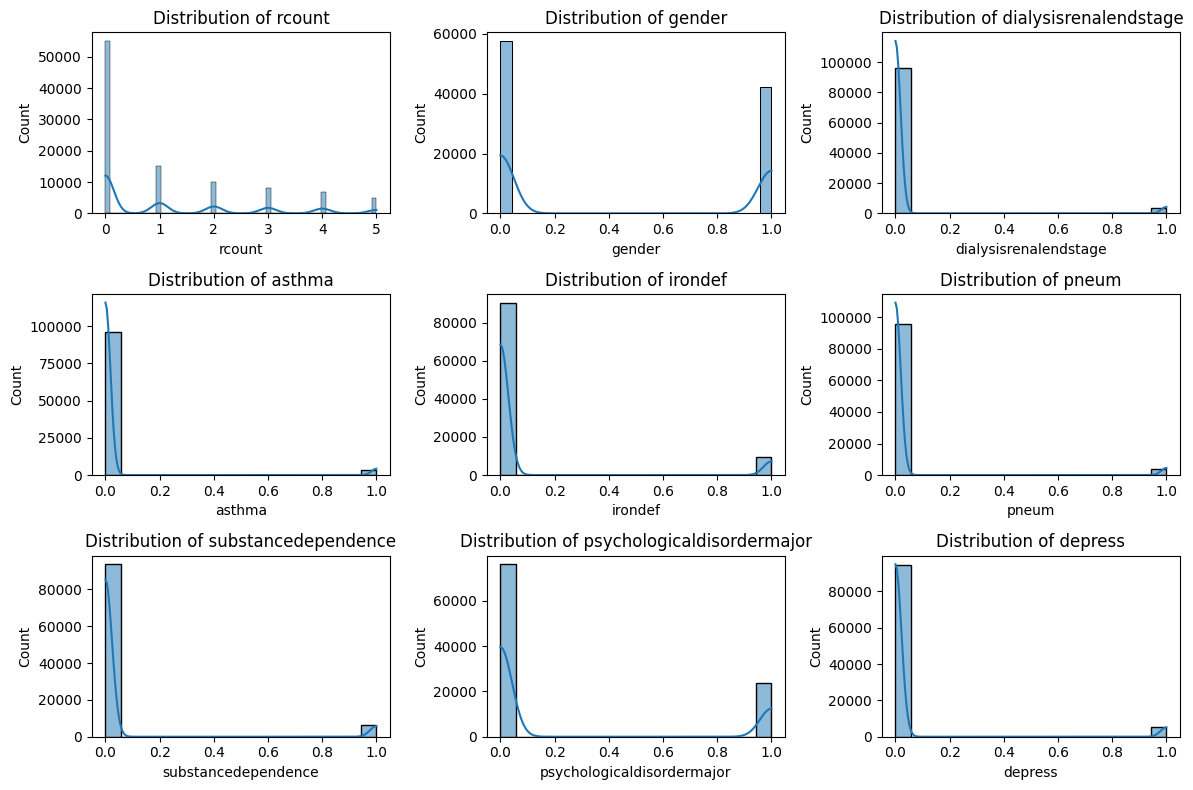

In [19]:
# Data Exploration: Visualize distributions of numerical features
plt.figure(figsize=(12, 8))
for i, column in enumerate(df_cleaned.columns[:-1], 1):  # exclude target from distributions
    if i <= 9:  # limiting to 9 plots
        plt.subplot(3, 3, i)
        sns.histplot(df_cleaned[column], kde=True)
        plt.title(f'Distribution of {column}')
plt.tight_layout()
plt.show()

In [20]:
# Handle outliers using z-scores (removing data points with z-score > 3)
df_cleaned = df_cleaned[(np.abs(stats.zscore(df_cleaned)) < 3).all(axis=1)]

# Handle imbalanced data by oversampling the minority class
df_majority = df_cleaned[df_cleaned.extended_stay == 0]
df_minority = df_cleaned[df_cleaned.extended_stay == 1]
df_minority_upsampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=42)
df_balanced = pd.concat([df_majority, df_minority_upsampled])

# Separate features and target
X = df_balanced.drop(columns=['extended_stay'])
y = df_balanced['extended_stay']

In [21]:
# Split the dataset: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Further split the training set into train and validation
X_train_final, X_val, y_train_final, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)


In [22]:
# Standardizing the data
scaler = StandardScaler()
X_train_final_scaled = scaler.fit_transform(X_train_final)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Define multiple models for comparison
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(random_state=42),
}

# Dictionary to store results
results = {}

# Train each model and evaluate performance using cross-validation
for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train_final_scaled, y_train_final)

    # Validate the model
    y_val_pred = model.predict(X_val_scaled)

    # Compute metrics
    accuracy = accuracy_score(y_val, y_val_pred)
    auc_score = roc_auc_score(y_val, y_val_pred)
    report = classification_report(y_val, y_val_pred)

    # Store results
    results[model_name] = {
        'Accuracy': accuracy,
        'AUC': auc_score,
        'Classification Report': report
    }

    print(f"Validation Performance for {model_name}:")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"AUC Score: {auc_score:.3f}")
    print(f"Classification Report:\n{report}")
    print("-" * 50)

# Hyperparameter Tuning using GridSearchCV
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_model = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train_final_scaled, y_train_final)

# Best model from GridSearch
best_rf_model = grid_search.best_estimator_

Training Logistic Regression...
Validation Performance for Logistic Regression:
Accuracy: 0.895
AUC Score: 0.895
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      9136
           1       0.88      0.91      0.90      8900

    accuracy                           0.90     18036
   macro avg       0.90      0.90      0.90     18036
weighted avg       0.90      0.90      0.90     18036

--------------------------------------------------
Training Random Forest...
Validation Performance for Random Forest:
Accuracy: 0.991
AUC Score: 0.991
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      9136
           1       0.98      1.00      0.99      8900

    accuracy                           0.99     18036
   macro avg       0.99      0.99      0.99     18036
weighted avg       0.99      0.99      0.99     18036

-----------------------------------

In [23]:
# Evaluate model performance on the validation set
y_val_pred = best_rf_model.predict(X_val_scaled)
val_report = classification_report(y_val, y_val_pred)
val_auc_score = roc_auc_score(y_val, y_val_pred)

print("Validation Classification Report:")
print(val_report)
print(f"Validation AUC Score: {val_auc_score}")

# Evaluate model performance on the test set
y_test_pred = best_rf_model.predict(X_test_scaled)
test_report = classification_report(y_test, y_test_pred)
test_auc_score = roc_auc_score(y_test, y_test_pred)

# Output the classification reports and AUC scores
print("Test Classification Report:")
print(test_report)
print(f"Test AUC Score: {test_auc_score}")


Validation Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98      9136
           1       0.95      1.00      0.98      8900

    accuracy                           0.98     18036
   macro avg       0.98      0.98      0.98     18036
weighted avg       0.98      0.98      0.98     18036

Validation AUC Score: 0.9766309106830123
Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98     11335
           1       0.95      1.00      0.98     11210

    accuracy                           0.98     22545
   macro avg       0.98      0.98      0.98     22545
weighted avg       0.98      0.98      0.98     22545

Test AUC Score: 0.9761358623731804


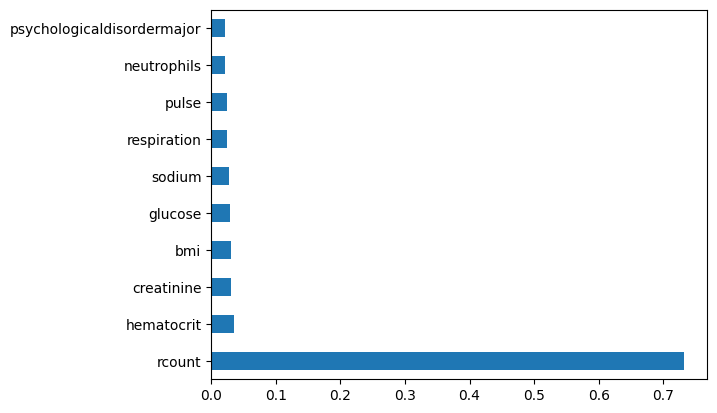

In [24]:
feature_importances = pd.Series(best_rf_model.feature_importances_, index=X_train.columns)
feature_importances.nlargest(10).plot(kind='barh')
plt.show()

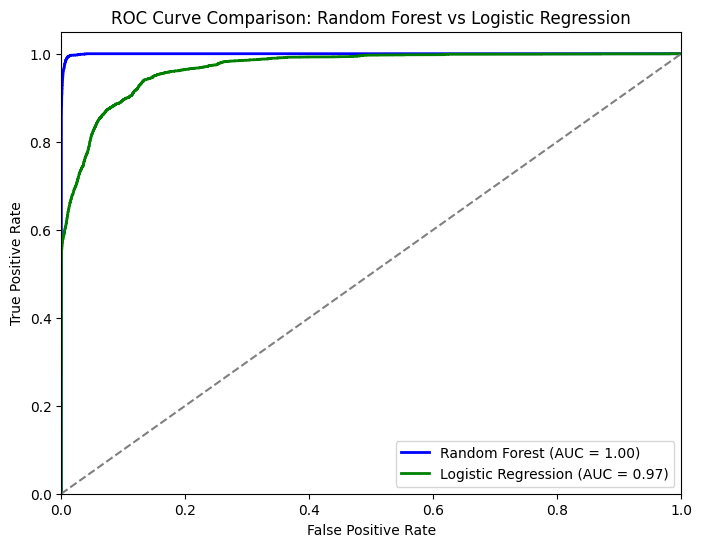

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Predict probabilities for the positive class
y_test_rf_prob = best_rf_model.predict_proba(X_test_scaled)[:, 1]  # Random Forest

# Assuming 'Logistic Regression' is the key for the Logistic Regression model in your 'models' dictionary
logistic_model = models['Logistic Regression']  # Get the trained Logistic Regression model
y_test_lr_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]  # Logistic Regression

# Compute ROC curve and AUC for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_rf_prob)
roc_auc_rf = roc_auc_score(y_test, y_test_rf_prob)

# Compute ROC curve and AUC for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_lr_prob)
roc_auc_lr = roc_auc_score(y_test, y_test_lr_prob)

# Plotting the ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_lr, tpr_lr, color='green', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line representing random guessing
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Random Forest vs Logistic Regression')
plt.legend(loc="lower right")
plt.show()